<a href="https://colab.research.google.com/github/gauravjha201/Deep_Learning_practices/blob/main/Copy_of_DL_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import os

In [2]:
tf.random.set_seed(42)
np.random.seed(42)


In [3]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


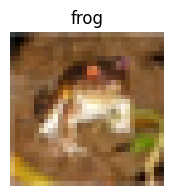

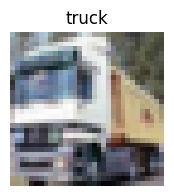

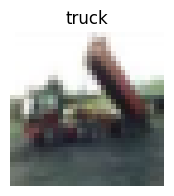

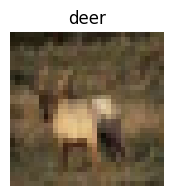

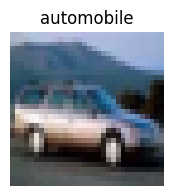

In [4]:
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def show_image(index):
  if index<0 or index>=len(x_train):
    return

  plt.figure(figsize=(2,2))
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')
  plt.show()

for i in range(5):
  show_image(i)



In [5]:

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)
y_train_cat shape: (50000, 10)
y_test_cat shape: (10000, 10)


In [6]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (7, 7), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 980,810 (3.74 MB)

 Trainable params: 980,810 (3.74 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
checkpoint_path = "cnn_cifar10_best_model.keras"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

start_time = time.time()

history = model.fit(
    x_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"Training Time: {training_time:.2f} seconds")

model.save("cnn_cifar10_final.keras")
print("Model saved successfully.")

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4003 - loss: 1.6428 - val_accuracy: 0.5534 - val_loss: 1.2575
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5698 - loss: 1.2137 - val_accuracy: 0.6366 - val_loss: 1.0383
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6432 - loss: 1.0141 - val_accuracy: 0.6691 - val_loss: 0.9377
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6966 - loss: 0.8680 - val_accuracy: 0.6882 - val_loss: 0.8909
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7427 - loss: 0.7369 - val_accuracy: 0.7005 - val_loss: 0.8714
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7757 - loss: 0.6384 - val_accuracy: 0.7037 - val_loss: 0.8800
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8019 - loss: 0.5546 - val_accuracy: 0.7168 - val_loss: 0.9110
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8249 - loss: 0.4913 - val_accuracy: 

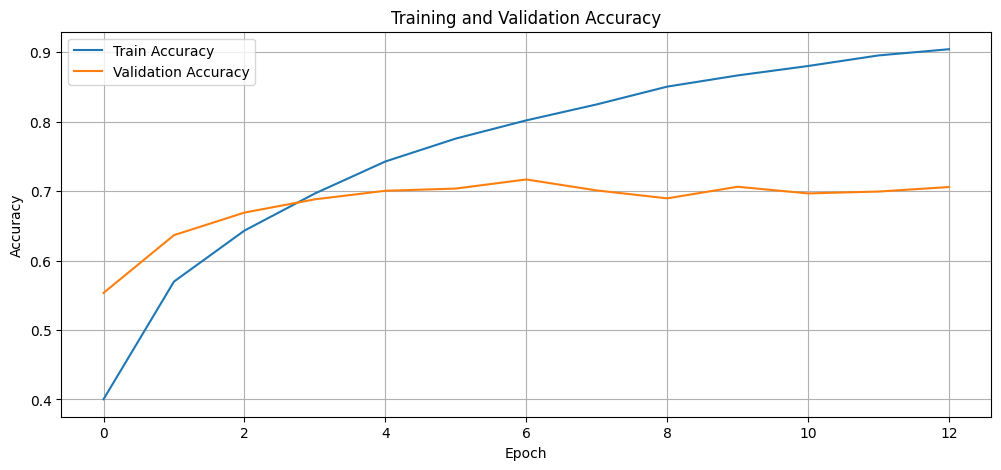

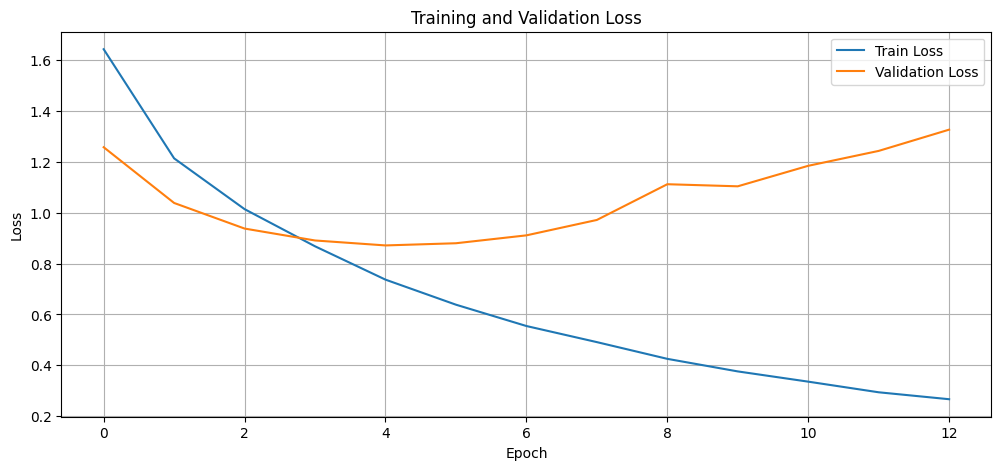

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [9]:
model=tf.keras.models.load_model('cnn_cifar10_best_model.keras')
print("Best model Loaded.")


Best model Loaded.


In [10]:
def evaluate_model(model, x_data, y_true_cat, y_true_labels, attack_name="Clean Data"):
    loss, acc = model.evaluate(x_data, y_true_cat, verbose=0)

    y_pred_probs = model.predict(x_data, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    precision = precision_score(y_true_labels, y_pred, average='weighted')
    recall = recall_score(y_true_labels, y_pred, average='weighted')
    f1 = f1_score(y_true_labels, y_pred, average='weighted')

    cm = confusion_matrix(y_true_labels, y_pred)

    print(f"\n--- {attack_name} Evaluation ---")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred, target_names=class_names))

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {attack_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return {
        "loss": loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }


--- Clean Data Evaluation ---
Loss: 0.9286
Accuracy: 0.7066
Precision: 0.7024
Recall: 0.7066
F1-score: 0.6981

Classification Report:
              precision    recall  f1-score   support

    airplane       0.74      0.79      0.76      1000
  automobile       0.88      0.77      0.82      1000
        bird       0.62      0.61      0.61      1000
         cat       0.61      0.33      0.42      1000
        deer       0.63      0.62      0.62      1000
         dog       0.62      0.59      0.61      1000
        frog       0.69      0.85      0.76      1000
       horse       0.70      0.82      0.75      1000
        ship       0.79      0.86      0.82      1000
       truck       0.75      0.84      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.70      0.71      0.70     10000
weighted avg       0.70      0.71      0.70     10000



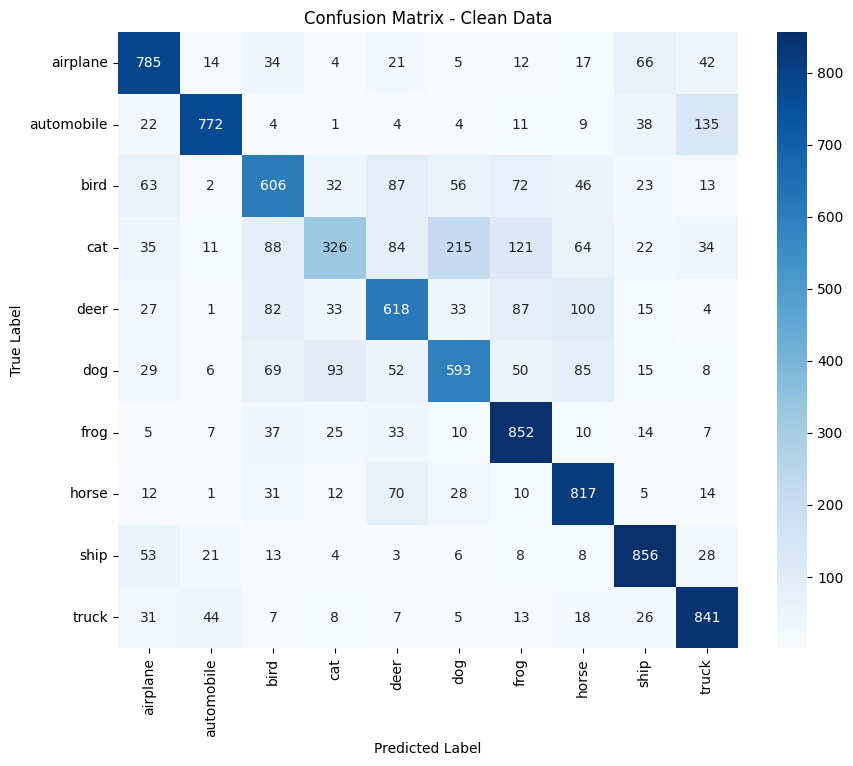

In [11]:
y_test_labels = y_test.flatten()

clean_results = evaluate_model(
    model,
    x_test,
    y_test_cat,
    y_test_labels,
    attack_name="Clean Data"
)

In [12]:
loss_object=tf.keras.losses.CategoricalCrossentropy()


In [13]:
def fgsm_attack(model, images, labels, epsilon=0.03):
    images=tf.convert_to_tensor(images)
    labels=tf.convert_to_tensor(labels)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions=model(images)
        loss=loss_object(labels,predictions)

    gradient=tape.gradient(loss,images)
    signed_grad=tf.sign(gradient)
    adv_images=images+epsilon*signed_grad
    adv_images=tf.clip_by_value(adv_images,0.0,1.0)

    return adv_images.numpy()

In [14]:
def bim_attack(model, images, labels, epsilon=0.03, alpha=0.005, iterations=10):
    images=tf.convert_to_tensor(images)
    labels=tf.convert_to_tensor(labels)

    original_images=images
    adv_images=tf.identity(images)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(adv_images)
            predictions=model(adv_images)
            loss=loss_object(labels,predictions)

        gradient=tape.gradient(loss,adv_images)
        signed_grad=tf.sign(gradient)

        adv_images=adv_images+alpha*signed_grad

        adv_images=tf.clip_by_value(adv_images,original_images-epsilon,original_images+epsilon)
        adv_images=tf.clip_by_value(adv_images,0.0,1.0)

    return adv_images.numpy()

In [15]:
def pgd_attack(model,images,labels,epsilon=0.03,alpha=0.005,iterations=20):
  images=tf.convert_to_tensor(images)
  labels=tf.convert_to_tensor(labels)

  adv_images=images+tf.random.uniform(tf.shape(images),-epsilon,epsilon)
  adv_images=tf.clip_by_value(adv_images,0,1)

  for i in range(iterations):
    with tf.GradientTape() as tape:
      tape.watch(adv_images)
      prediction=model(adv_images)
      loss=loss_object(labels,prediction)
    gradient=tape.gradient(loss,adv_images)
    singed_grad=tf.sign(gradient)

    adv_images=adv_images+alpha*singed_grad

    adv_images=tf.clip_by_value(adv_images,images-epsilon,images+epsilon)
    adv_images=tf.clip_by_value(adv_images,0,1)

  return adv_images.numpy()

In [16]:
def generate_adversarial_dataset(attack_fn,model,x_data,y_data,batch_size=256,**attack_params):
  adv_examples=[]
  n=len(x_data)

  for i in range(0,n,batch_size):
    x_batch=x_data[i:i+batch_size]
    y_batch=y_data[i:i+batch_size]

    adv_batch=attack_fn(model,x_batch,y_batch,**attack_params)
    adv_examples.append(adv_batch)

  return np.concatenate(adv_examples,axis=0)


Generating FGSM adversarial examples for epsilon = 0.01

--- FGSM (epsilon=0.01) Evaluation ---
Loss: 2.8304
Accuracy: 0.3524
Precision: 0.3385
Recall: 0.3524
F1-score: 0.3406

Classification Report:
              precision    recall  f1-score   support

    airplane       0.43      0.47      0.45      1000
  automobile       0.56      0.39      0.46      1000
        bird       0.19      0.20      0.20      1000
         cat       0.09      0.04      0.06      1000
        deer       0.15      0.15      0.15      1000
         dog       0.27      0.23      0.25      1000
        frog       0.38      0.48      0.42      1000
       horse       0.39      0.50      0.43      1000
        ship       0.51      0.54      0.52      1000
       truck       0.42      0.54      0.47      1000

    accuracy                           0.35     10000
   macro avg       0.34      0.35      0.34     10000
weighted avg       0.34      0.35      0.34     10000



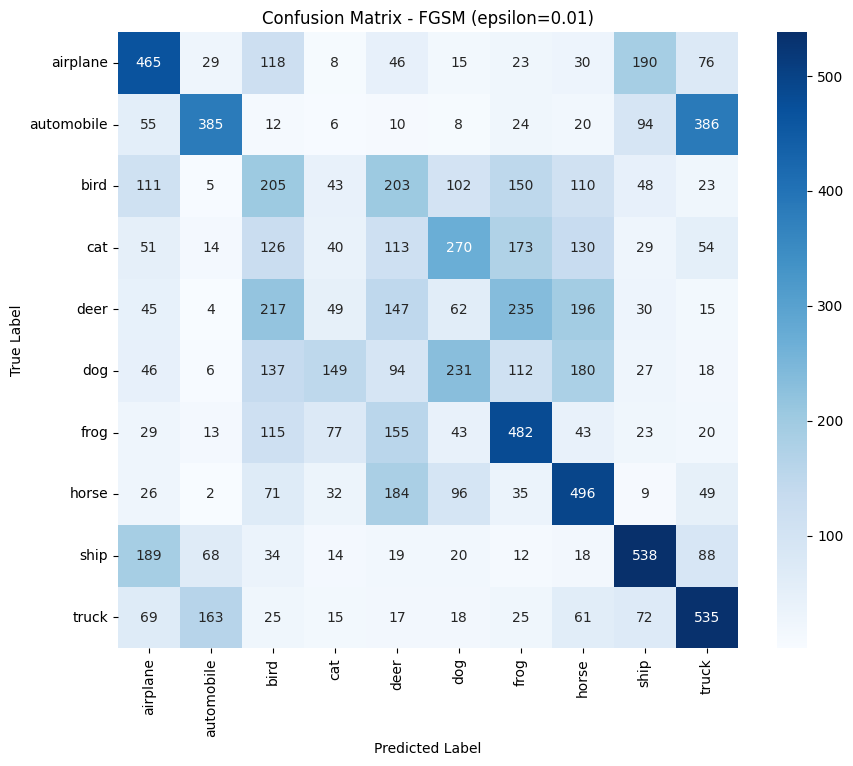


Generating FGSM adversarial examples for epsilon = 0.03

--- FGSM (epsilon=0.03) Evaluation ---
Loss: 6.5509
Accuracy: 0.0785
Precision: 0.0767
Recall: 0.0785
F1-score: 0.0768

Classification Report:
              precision    recall  f1-score   support

    airplane       0.15      0.16      0.15      1000
  automobile       0.08      0.05      0.06      1000
        bird       0.03      0.03      0.03      1000
         cat       0.00      0.00      0.00      1000
        deer       0.01      0.01      0.01      1000
         dog       0.06      0.05      0.06      1000
        frog       0.09      0.10      0.10      1000
       horse       0.10      0.11      0.11      1000
        ship       0.16      0.14      0.15      1000
       truck       0.09      0.12      0.11      1000

    accuracy                           0.08     10000
   macro avg       0.08      0.08      0.08     10000
weighted avg       0.08      0.08      0.08     10000



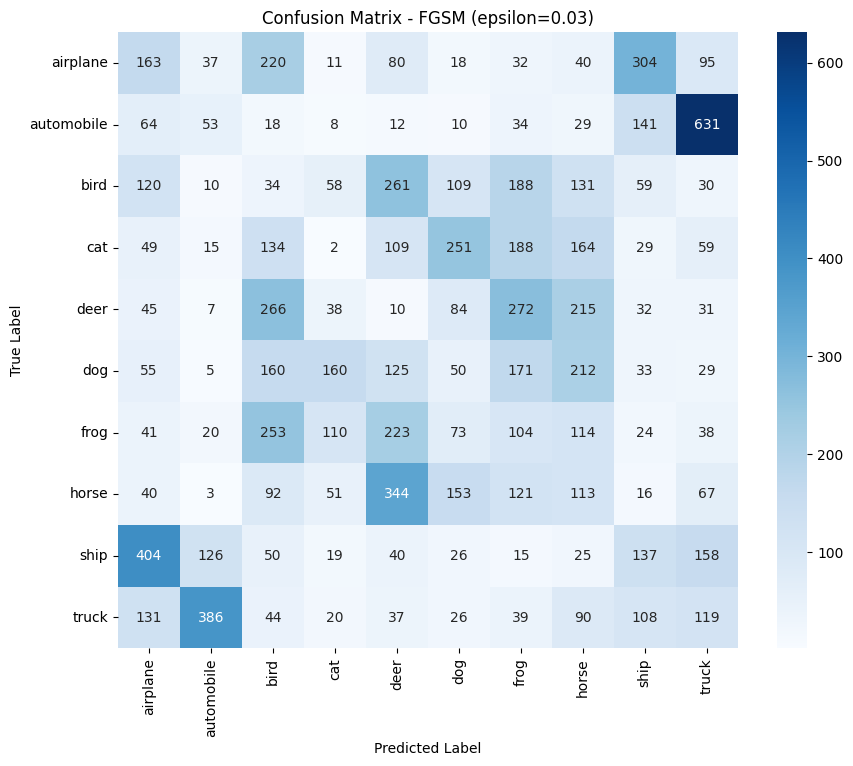


Generating FGSM adversarial examples for epsilon = 0.05

--- FGSM (epsilon=0.05) Evaluation ---
Loss: 8.9455
Accuracy: 0.0248
Precision: 0.0239
Recall: 0.0248
F1-score: 0.0241

Classification Report:
              precision    recall  f1-score   support

    airplane       0.08      0.08      0.08      1000
  automobile       0.01      0.01      0.01      1000
        bird       0.01      0.02      0.01      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.01      0.01      0.01      1000
        frog       0.02      0.03      0.02      1000
       horse       0.03      0.04      0.04      1000
        ship       0.05      0.04      0.04      1000
       truck       0.02      0.03      0.02      1000

    accuracy                           0.02     10000
   macro avg       0.02      0.02      0.02     10000
weighted avg       0.02      0.02      0.02     10000



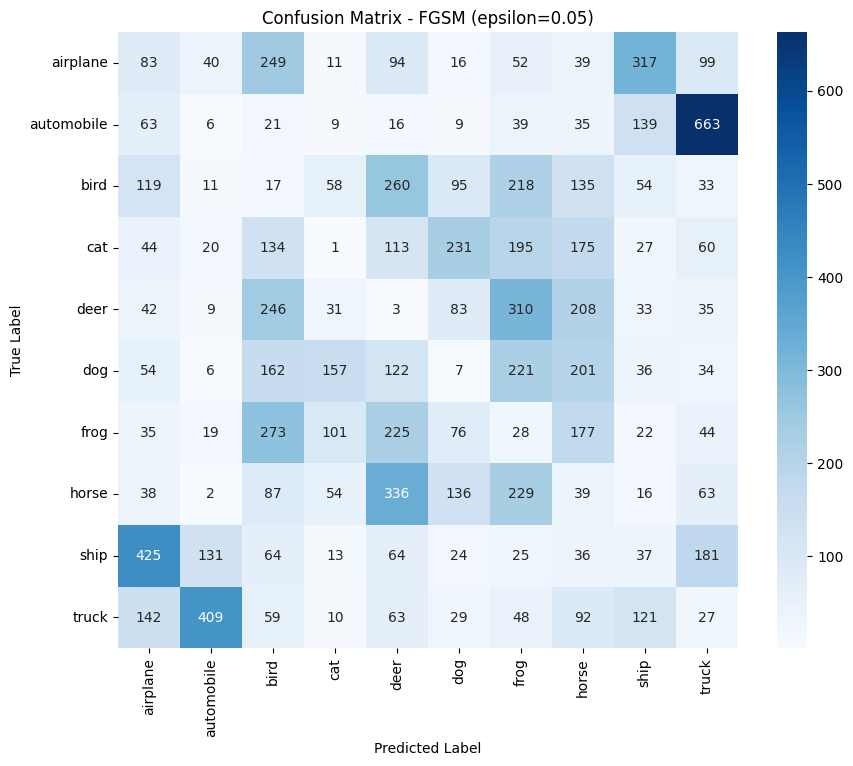


Generating FGSM adversarial examples for epsilon = 0.1

--- FGSM (epsilon=0.1) Evaluation ---
Loss: 11.4545
Accuracy: 0.0128
Precision: 0.0112
Recall: 0.0128
F1-score: 0.0114

Classification Report:
              precision    recall  f1-score   support

    airplane       0.04      0.03      0.04      1000
  automobile       0.00      0.00      0.00      1000
        bird       0.01      0.01      0.01      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.00      0.00      0.00      1000
        frog       0.02      0.04      0.02      1000
       horse       0.03      0.03      0.03      1000
        ship       0.01      0.01      0.01      1000
       truck       0.01      0.01      0.01      1000

    accuracy                           0.01     10000
   macro avg       0.01      0.01      0.01     10000
weighted avg       0.01      0.01      0.01     10000



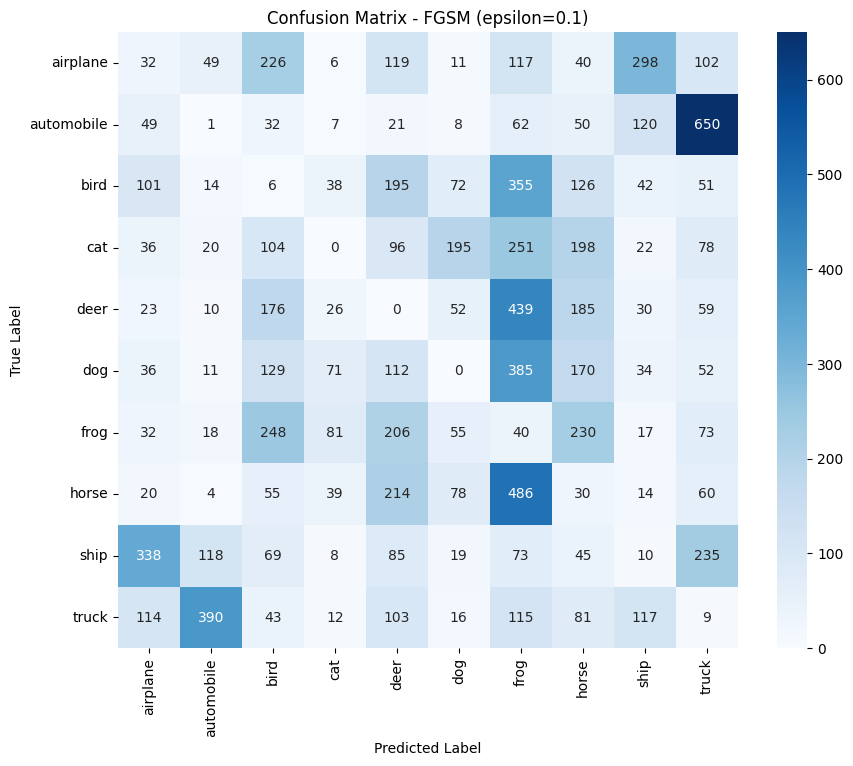

In [17]:
fgsm_epsilons = [0.01, 0.03, 0.05, 0.1]
fgsm_results = {}

for eps in fgsm_epsilons:
    print(f"\nGenerating FGSM adversarial examples for epsilon = {eps}")
    x_test_fgsm = generate_adversarial_dataset(
        fgsm_attack, model, x_test, y_test_cat, epsilon=eps
    )

    results = evaluate_model(
        model,
        x_test_fgsm,
        y_test_cat,
        y_test_labels,
        attack_name=f"FGSM (epsilon={eps})"
    )
    fgsm_results[eps] = results


Generating BIM adversarial examples...

--- BIM (epsilon=0.03, alpha=0.005, iter=10) Evaluation ---
Loss: 11.8552
Accuracy: 0.0168
Precision: 0.0154
Recall: 0.0168
F1-score: 0.0159

Classification Report:
              precision    recall  f1-score   support

    airplane       0.05      0.05      0.05      1000
  automobile       0.01      0.01      0.01      1000
        bird       0.01      0.01      0.01      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.01      0.01      0.01      1000
        frog       0.01      0.01      0.01      1000
       horse       0.03      0.04      0.03      1000
        ship       0.02      0.02      0.02      1000
       truck       0.01      0.02      0.02      1000

    accuracy                           0.02     10000
   macro avg       0.02      0.02      0.02     10000
weighted avg       0.02      0.02      0.02     10000



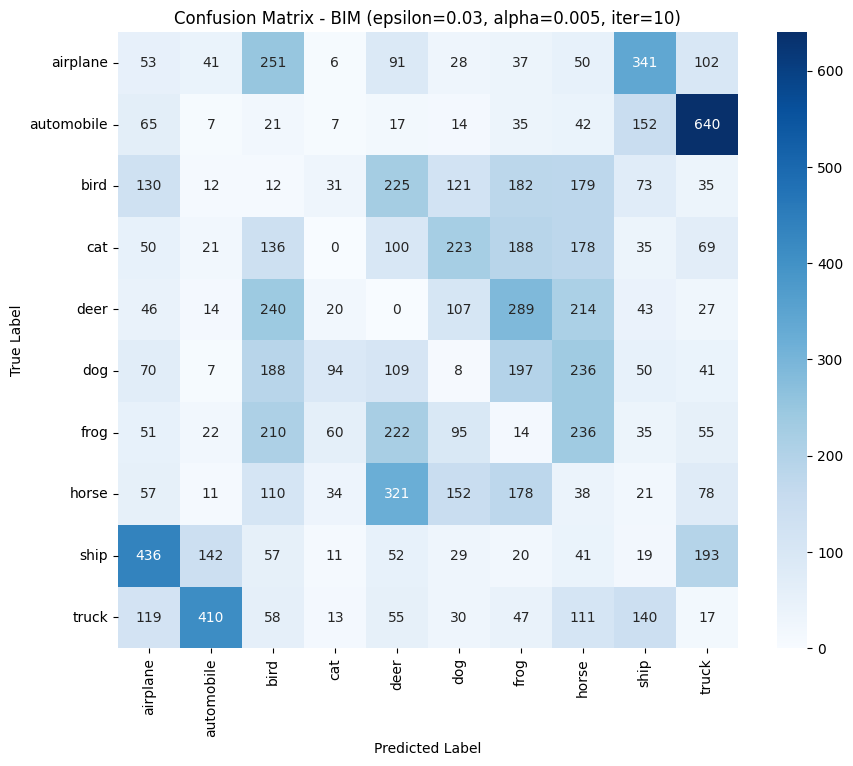

In [18]:
print("\nGenerating BIM adversarial examples...")
x_test_bim = generate_adversarial_dataset(
    bim_attack,
    model,
    x_test,
    y_test_cat,
    epsilon=0.03,
    alpha=0.005,
    iterations=10
)

bim_results = evaluate_model(
    model,
    x_test_bim,
    y_test_cat,
    y_test_labels,
    attack_name="BIM (epsilon=0.03, alpha=0.005, iter=10)"
)


Generating PGD adversarial examples...

--- PGD (epsilon=0.03, alpha=0.005, iter=20) Evaluation ---
Loss: 12.8729
Accuracy: 0.0129
Precision: 0.0121
Recall: 0.0129
F1-score: 0.0124

Classification Report:
              precision    recall  f1-score   support

    airplane       0.04      0.04      0.04      1000
  automobile       0.01      0.01      0.01      1000
        bird       0.01      0.01      0.01      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.01      0.01      0.01      1000
        frog       0.01      0.01      0.01      1000
       horse       0.02      0.03      0.02      1000
        ship       0.02      0.01      0.01      1000
       truck       0.01      0.01      0.01      1000

    accuracy                           0.01     10000
   macro avg       0.01      0.01      0.01     10000
weighted avg       0.01      0.01      0.01     10000



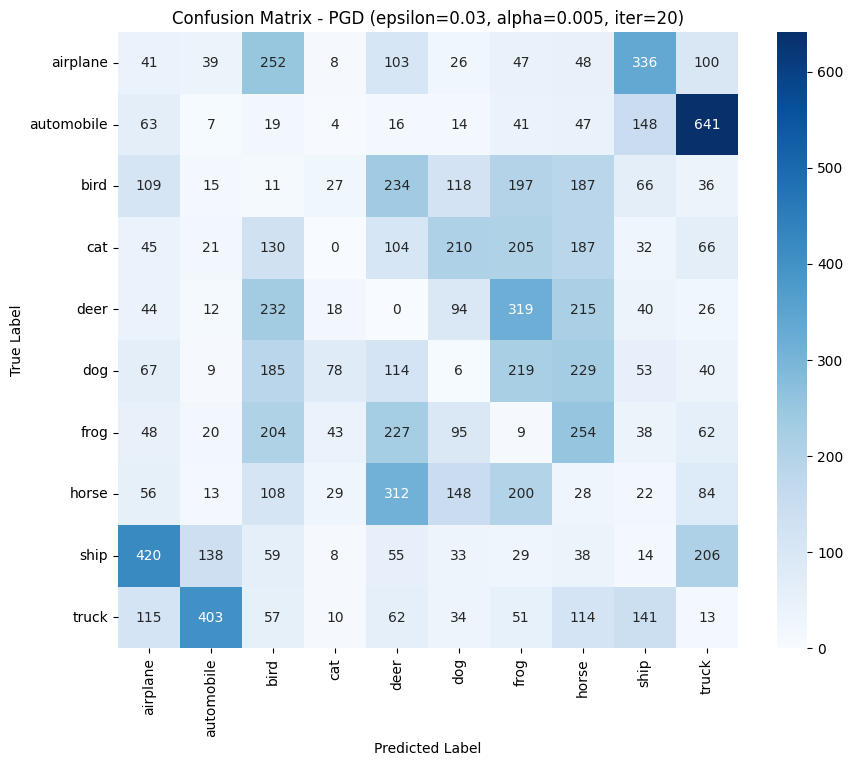

In [19]:
print("\nGenerating PGD adversarial examples...")
x_test_pgd = generate_adversarial_dataset(
    pgd_attack,
    model,
    x_test,
    y_test_cat,
    epsilon=0.03,
    alpha=0.005,
    iterations=20
)

pgd_results = evaluate_model(
    model,
    x_test_pgd,
    y_test_cat,
    y_test_labels,
    attack_name="PGD (epsilon=0.03, alpha=0.005, iter=20)"
)

In [20]:
results_summary = []

results_summary.append([
    "Clean",
    clean_results["loss"],
    clean_results["accuracy"],
    clean_results["precision"],
    clean_results["recall"],
    clean_results["f1_score"]
])

for eps, res in fgsm_results.items():
    results_summary.append([
        f"FGSM eps={eps}",
        res["loss"],
        res["accuracy"],
        res["precision"],
        res["recall"],
        res["f1_score"]
    ])

results_summary.append([
    "BIM",
    bim_results["loss"],
    bim_results["accuracy"],
    bim_results["precision"],
    bim_results["recall"],
    bim_results["f1_score"]
])

results_summary.append([
    "PGD",
    pgd_results["loss"],
    pgd_results["accuracy"],
    pgd_results["precision"],
    pgd_results["recall"],
    pgd_results["f1_score"]
])

print("\nFinal Comparison:")
print(f"{'Attack':<20} {'Loss':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-score':<10}")
for row in results_summary:
    print(f"{row[0]:<20} {row[1]:<10.4f} {row[2]:<10.4f} {row[3]:<10.4f} {row[4]:<10.4f} {row[5]:<10.4f}")


Final Comparison:
Attack               Loss       Accuracy   Precision  Recall     F1-score  
Clean                0.9286     0.7066     0.7024     0.7066     0.6981    
FGSM eps=0.01        2.8304     0.3524     0.3385     0.3524     0.3406    
FGSM eps=0.03        6.5509     0.0785     0.0767     0.0785     0.0768    
FGSM eps=0.05        8.9455     0.0248     0.0239     0.0248     0.0241    
FGSM eps=0.1         11.4545    0.0128     0.0112     0.0128     0.0114    
BIM                  11.8552    0.0168     0.0154     0.0168     0.0159    
PGD                  12.8729    0.0129     0.0121     0.0129     0.0124    


In [21]:
def visualize_adversarial_examples(model, x_original, y_true, x_adversarial, class_names, num_examples=10):
    y_true = y_true.flatten()

    pred_original = np.argmax(model.predict(x_original[:num_examples], verbose=0), axis=1)
    pred_adv = np.argmax(model.predict(x_adversarial[:num_examples], verbose=0), axis=1)

    plt.figure(figsize=(15, num_examples * 3))

    for i in range(num_examples):
        # Original
        plt.subplot(num_examples, 3, i*3 + 1)
        plt.imshow(x_original[i])
        plt.title(f"Original\nTrue: {class_names[y_true[i]]}\nPred: {class_names[pred_original[i]]}")
        plt.axis('off')

        # Adversarial
        plt.subplot(num_examples, 3, i*3 + 2)
        plt.imshow(x_adversarial[i])
        plt.title(f"Adversarial\nPred: {class_names[pred_adv[i]]}")
        plt.axis('off')

        # Perturbation
        perturbation = x_adversarial[i] - x_original[i]
        perturbation_display = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)

        plt.subplot(num_examples, 3, i*3 + 3)
        plt.imshow(perturbation_display)
        plt.title("Perturbation")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

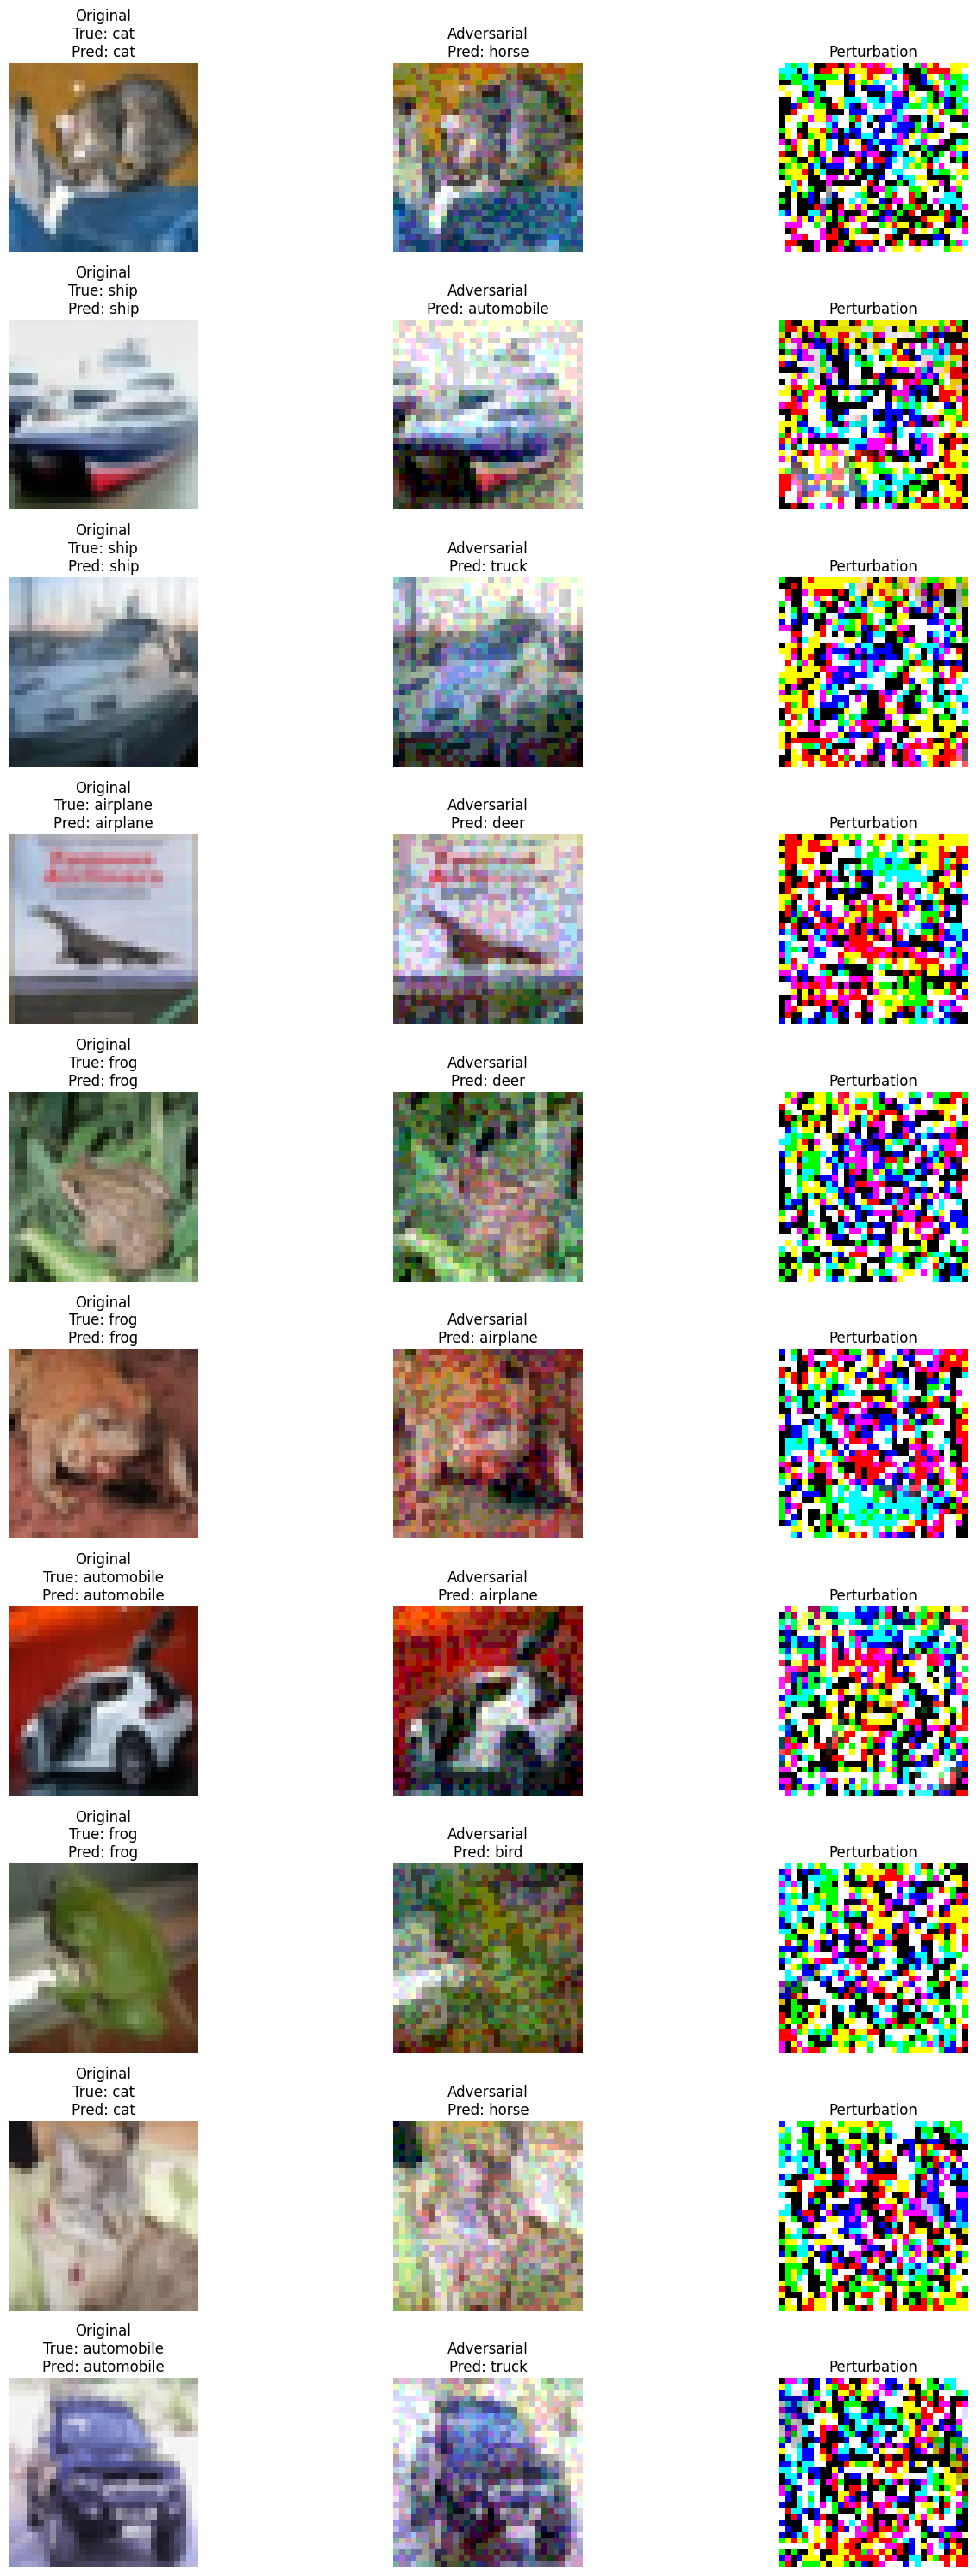

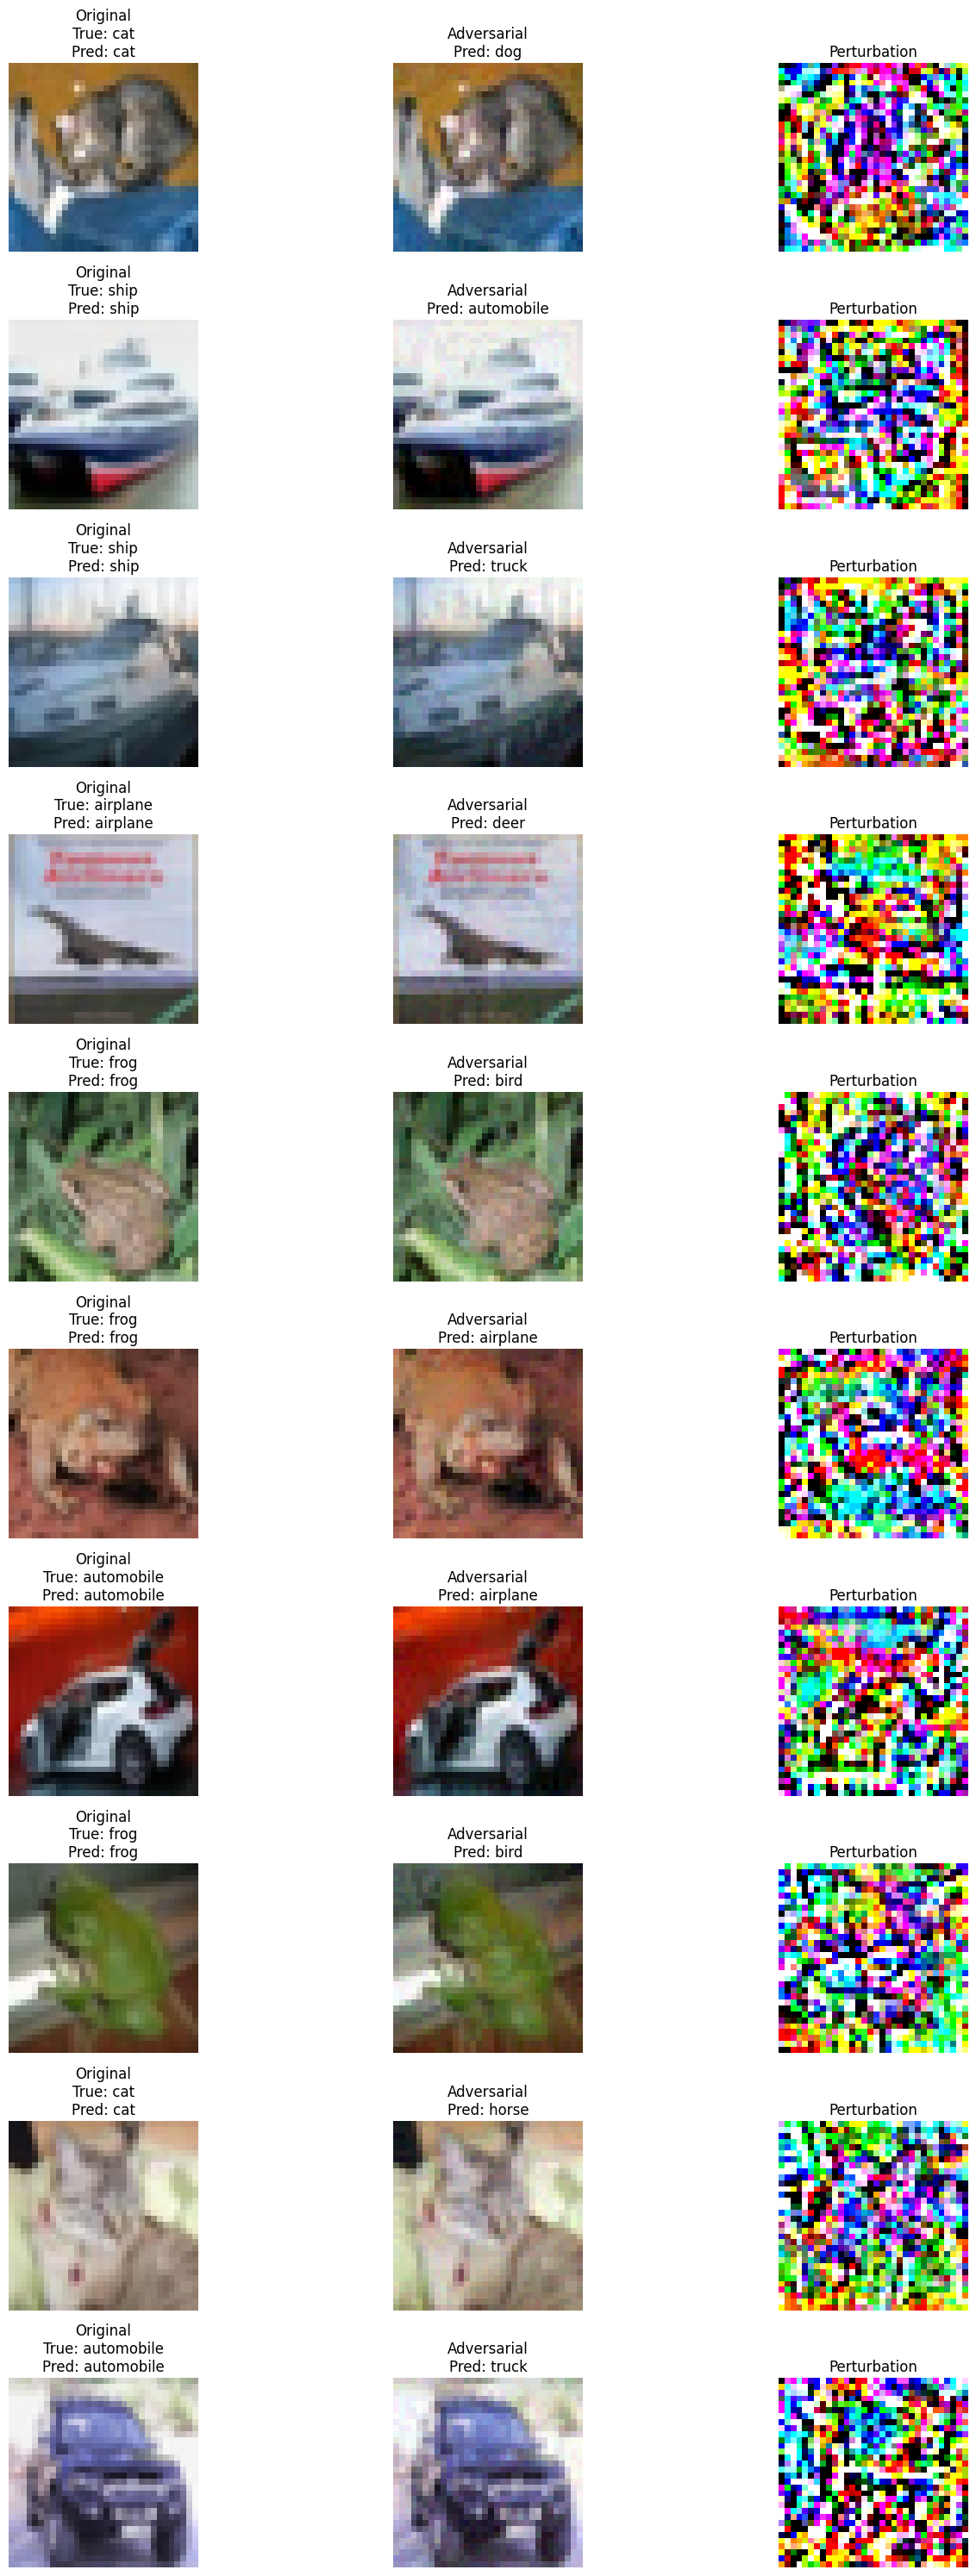

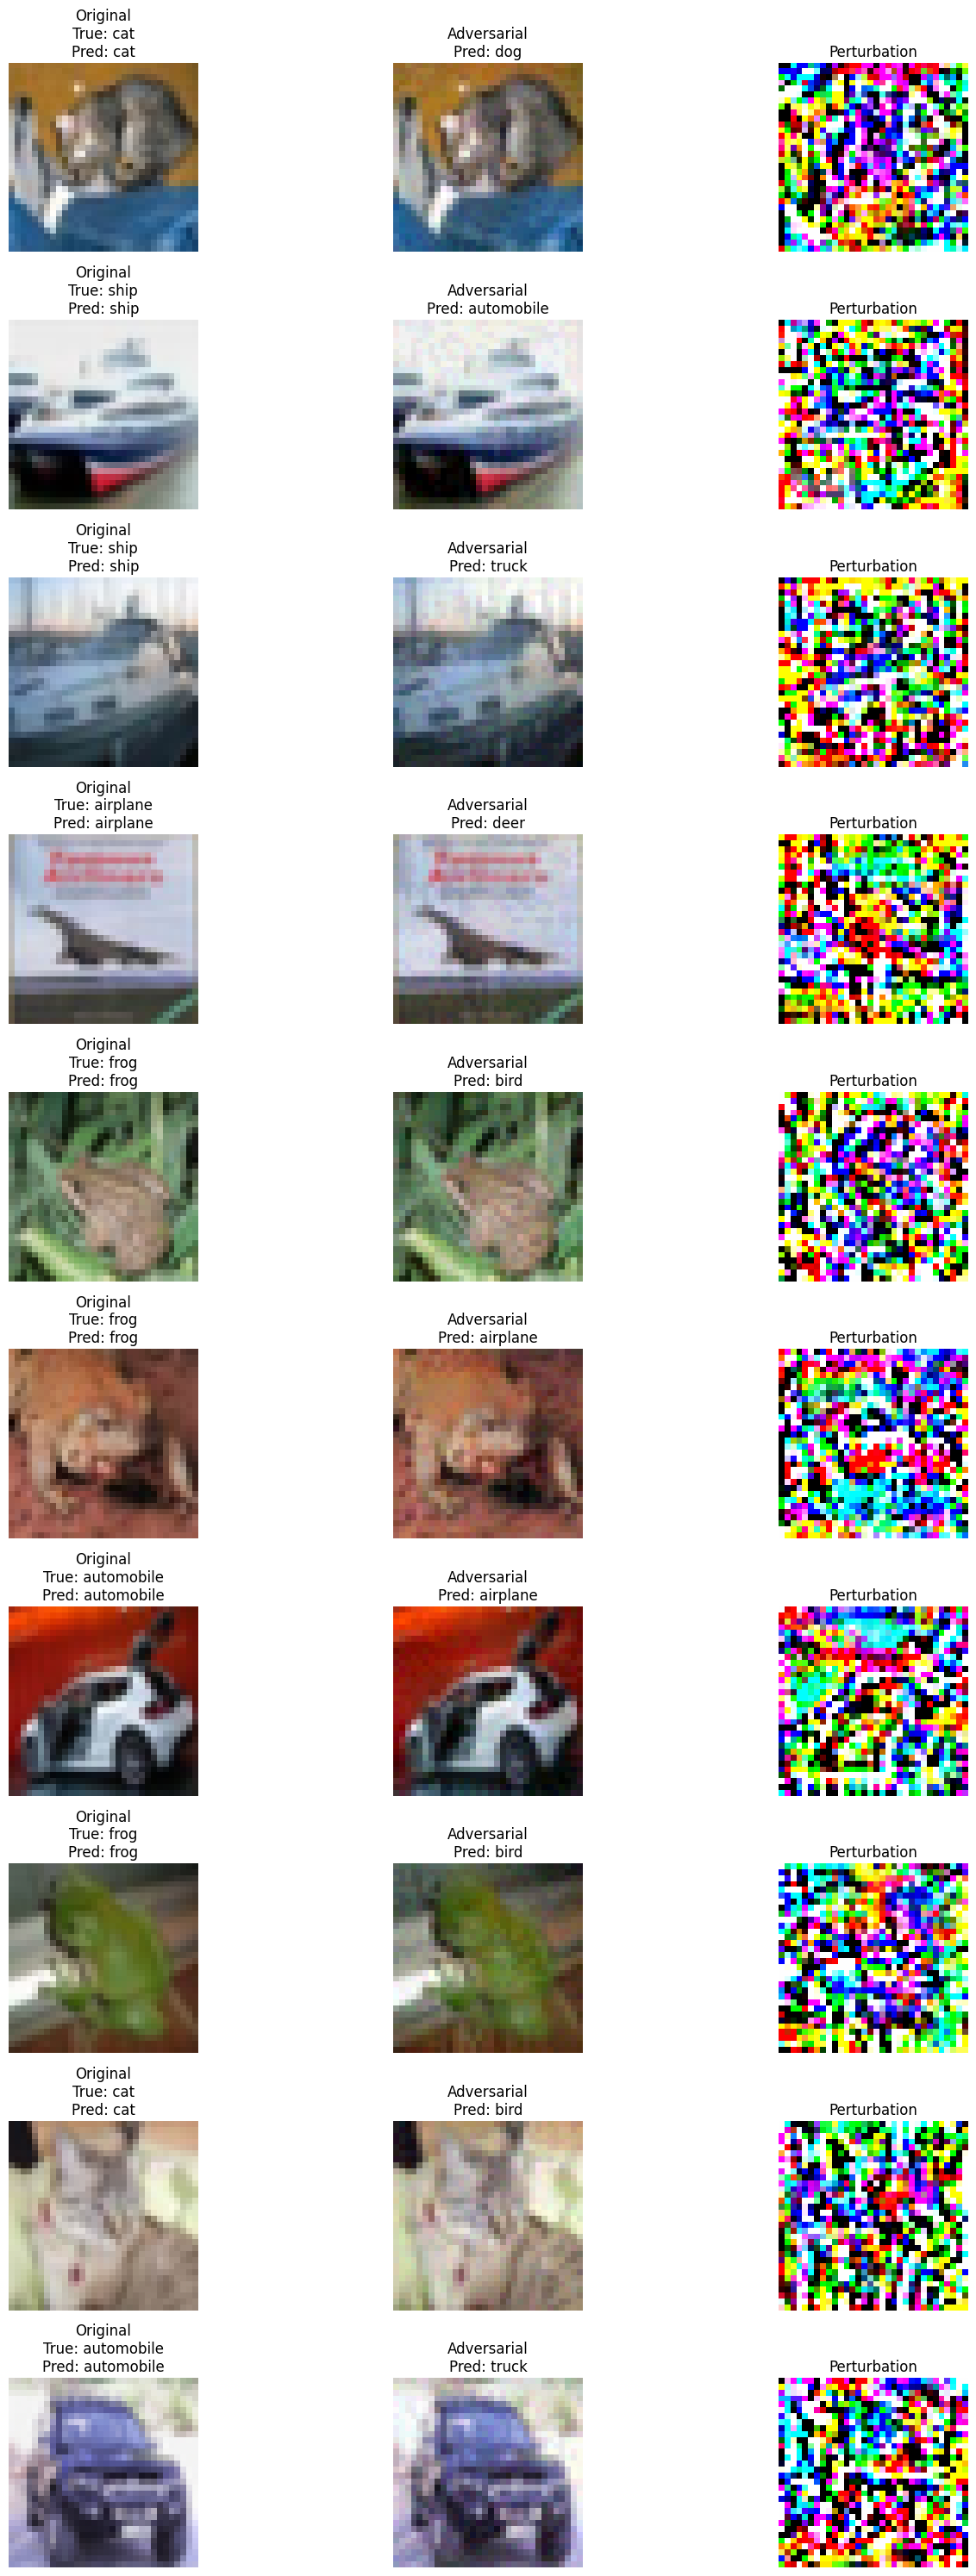

In [22]:
visualize_adversarial_examples(model, x_test, y_test, x_test_fgsm, class_names, num_examples=10)
visualize_adversarial_examples(model, x_test, y_test, x_test_bim, class_names, num_examples=10)
visualize_adversarial_examples(model, x_test, y_test, x_test_pgd, class_names, num_examples=10)

In [23]:
np.save("x_test_fgsm_eps_003.npy", x_test_fgsm)
np.save("x_test_bim.npy", x_test_bim)
np.save("x_test_pgd.npy", x_test_pgd)

print("Adversarial datasets saved.")

Adversarial datasets saved.


In [24]:
comparison_table = []

# Clean
comparison_table.append(["Clean", "-", clean_results["accuracy"]])

# FGSM
for eps, res in fgsm_results.items():
    comparison_table.append(["FGSM", eps, res["accuracy"]])

# BIM
comparison_table.append(["BIM", 0.03, bim_results["accuracy"]])

# PGD
comparison_table.append(["PGD", 0.03, pgd_results["accuracy"]])

# Print Table
print("\nComparative Analysis Table:")
print(f"{'Attack':<10} {'Epsilon':<10} {'Test Accuracy':<15}")
print("-" * 35)

for row in comparison_table:
    print(f"{row[0]:<10} {str(row[1]):<10} {row[2]:<15.4f}")


Comparative Analysis Table:
Attack     Epsilon    Test Accuracy  
-----------------------------------
Clean      -          0.7066         
FGSM       0.01       0.3524         
FGSM       0.03       0.0785         
FGSM       0.05       0.0248         
FGSM       0.1        0.0128         
BIM        0.03       0.0168         
PGD        0.03       0.0129         
